SECTION 1 — Load Data

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

nifty = pd.read_csv("../data/processed/nifty_clean.csv", index_col='Date', parse_dates=True)

SECTION 2 — Prepare Features

In [3]:
features = nifty[['Returns', 'Volatility']].dropna()

SECTION 3 — Train HMM Model

In [4]:
from hmmlearn.hmm import GaussianHMM

model = GaussianHMM(n_components=2, covariance_type="full", n_iter=1000)
model.fit(features)

GaussianHMM(covariance_type='full', n_components=2, n_iter=1000)

SECTION 4 — Predict Regimes

In [5]:
hidden_states = model.predict(features)

features['Regime'] = hidden_states

SECTION 5 — Merge with Original Data

In [6]:
nifty = nifty.loc[features.index]
nifty['Regime'] = hidden_states

SECTION 6 — VISUALIZE REGIMES

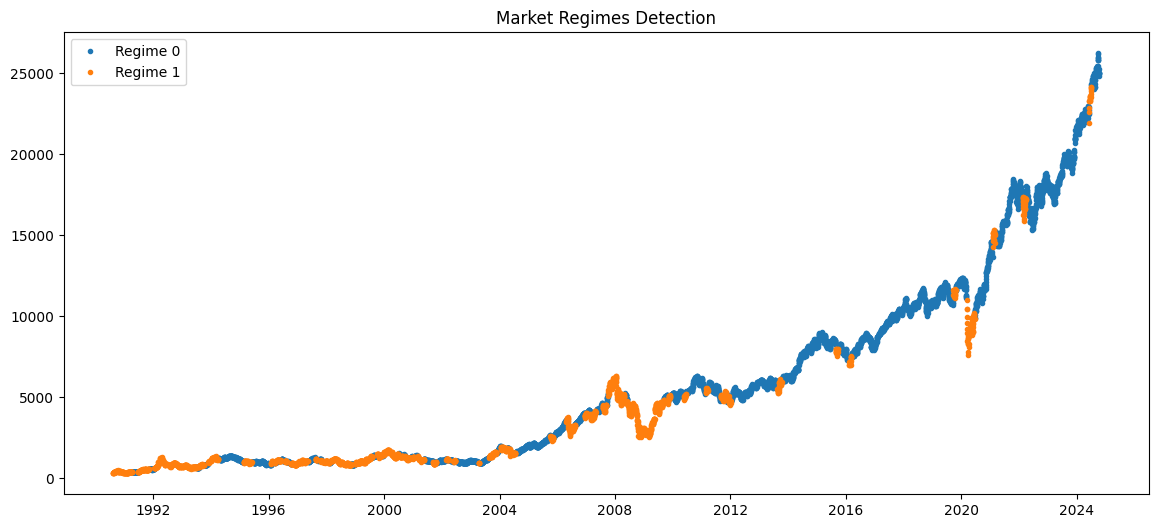

In [7]:
plt.figure(figsize=(14,6))

for i in range(2):
    plt.plot(nifty[nifty['Regime'] == i].index,
             nifty[nifty['Regime'] == i]['Close'],
             '.', label=f'Regime {i}')

plt.title("Market Regimes Detection")
plt.legend()
plt.show()

SECTION 7 — COLOR PLOT

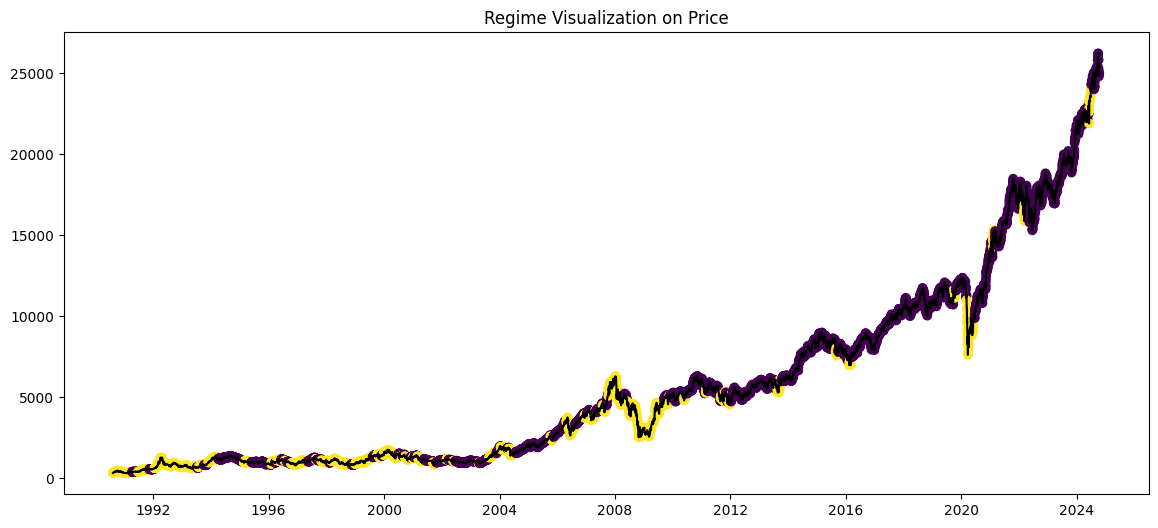

In [8]:
plt.figure(figsize=(14,6))

plt.plot(nifty['Close'], color='black')

plt.scatter(nifty.index, nifty['Close'], c=nifty['Regime'], cmap='viridis')

plt.title("Regime Visualization on Price")
plt.show()

SECTION 8 — UNDERSTAND REGIME SWITCHING

In [9]:
model.transmat_

array([[0.99072014, 0.00927986],
       [0.0181562 , 0.9818438 ]])